# MACHINE LEARNING FOR DATA ANALYSIS
## Dataset: Default of Credit Card Clients

# 1. Splitting Dataset
70/15/15
70 train
15 validation
15 test

### Pipeline
Data → Preprocessing → Train → Evaluate → Deploy

## 1. Import Data

In [12]:
from ucimlrepo import fetch_ucirepo
default_of_credit_card_clients = fetch_ucirepo(id=350) 
  
# data (as pandas dataframes) 
X = default_of_credit_card_clients.data.features 
y = default_of_credit_card_clients.data.targets 
  
# metadata 
print(default_of_credit_card_clients.metadata) 
  
# variable information 
print(default_of_credit_card_clients.variables) 


{'uci_id': 350, 'name': 'Default of Credit Card Clients', 'repository_url': 'https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients', 'data_url': 'https://archive.ics.uci.edu/static/public/350/data.csv', 'abstract': "This research aimed at the case of customers' default payments in Taiwan and compares the predictive accuracy of probability of default among six data mining methods.", 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 30000, 'num_features': 23, 'feature_types': ['Integer', 'Real'], 'demographics': ['Sex', 'Education Level', 'Marital Status', 'Age'], 'target_col': ['Y'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Fri Mar 29 2024', 'dataset_doi': '10.24432/C55S3H', 'creators': ['I-Cheng Yeh'], 'intro_paper': {'ID': 365, 'type': 'NATIVE', 'title': 'The comparisons of data mining techniques for the predictive accuracy of 

## 2. Cleaning Data

In [13]:
import pandas as pd
import numpy as np

# 1. Combine features and target into a single DataFrame
df = pd.concat([X, y], axis=1)

# 2. Rename columns from X1–X23 to descriptive names
column_mapping = {
    'X1': 'Credit_Limit', 'X2': 'Gender', 'X3': 'Education', 'X4': 'Marriage', 'X5': 'Age',
    'X6': 'PAY_1',  'X7': 'PAY_2',  'X8': 'PAY_3',
    'X9': 'PAY_4',  'X10': 'PAY_5', 'X11': 'PAY_6',
    'X12': 'BILL_AMT_1', 'X13': 'BILL_AMT_2', 'X14': 'BILL_AMT_3',
    'X15': 'BILL_AMT_4', 'X16': 'BILL_AMT_5', 'X17': 'BILL_AMT_6',
    'X18': 'PAY_AMT_1', 'X19': 'PAY_AMT_2', 'X20': 'PAY_AMT_3',
    'X21': 'PAY_AMT_4', 'X22': 'PAY_AMT_5', 'X23': 'PAY_AMT_6',
    'Y': 'Default_Payment_Next_Month'
}
df.rename(columns=column_mapping, inplace=True)

# 3. Fix Education: undocumented categories (0, 5, 6) → 4 (Others)
df['Education'] = df['Education'].replace([0, 5, 6], 4)

# 4. Fix Marriage: undocumented category (0) → 3 (Others)
df['Marriage'] = df['Marriage'].replace(0, 3)

# 5. Verify cleaning results
print("=== Data Cleaning Complete ===")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Education unique values: {sorted(df['Education'].unique())}")
print(f"Marriage  unique values: {sorted(df['Marriage'].unique())}")
print(f"PAY_1     unique values: {sorted(df['PAY_1'].unique())}")
df.head(3)

=== Data Cleaning Complete ===
Shape: 30,000 rows × 24 columns
Missing values: 0
Education unique values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Marriage  unique values: [np.int64(1), np.int64(2), np.int64(3)]
PAY_1     unique values: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


,Credit_Limit,Gender,Education,Marriage,Age,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT_4,BILL_AMT_5,BILL_AMT_6,PAY_AMT_1,PAY_AMT_2,PAY_AMT_3,PAY_AMT_4,PAY_AMT_5,PAY_AMT_6,Default_Payment_Next_Month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0


## 3. Preprocess - Split

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Separate features and target
target_col = 'Default_Payment_Next_Month'
X = df.drop(columns=[target_col])
y = df[target_col]

# 2. Identify column types
categorical_cols = ['Gender', 'Education', 'Marriage']
numerical_cols = [c for c in X.columns if c not in categorical_cols]

# 3. One-hot encode categorical features
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# 4. Split: 70% train, 15% validation, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X_encoded, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# 5. Scale numerical features (fit on train only)
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_val[numerical_cols]   = scaler.transform(X_val[numerical_cols])
X_test[numerical_cols]  = scaler.transform(X_test[numerical_cols])

print(f"Train:      {X_train.shape[0]:,} samples ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Validation: {X_val.shape[0]:,} samples ({X_val.shape[0]/len(df)*100:.1f}%)")
print(f"Test:       {X_test.shape[0]:,} samples ({X_test.shape[0]/len(df)*100:.1f}%)")
print(f"\nFeatures after encoding: {X_train.shape[1]}")
print(f"Target distribution (train): {y_train.value_counts(normalize=True).to_dict()}")

Train:      21,000 samples (70.0%)
Validation: 4,500 samples (15.0%)
Test:       4,500 samples (15.0%)

Features after encoding: 26
Target distribution (train): {0: 0.7788095238095238, 1: 0.2211904761904762}


## 4. Training

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Dictionary to collect all trained models and their scores
results = {}

### 4.1 Logistic Regression

**How it works:** Logistic Regression models the probability that a sample belongs to a class using the sigmoid function:

$$P(y=1 \mid x) = \frac{1}{1 + e^{-(\mathbf{w} \cdot \mathbf{x} + b)}}$$

It finds a **linear decision boundary** in the feature space. If the probability exceeds 0.5, the sample is classified as "Default".

**Why use it here:**
- Fast to train, easy to interpret (coefficients show feature importance)
- Good baseline model — if it performs well, the problem is linearly separable
- Works well with scaled numerical features (which we already applied)

**Key parameters:**
- `max_iter=1000` — more iterations to ensure convergence on this dataset
- `random_state=42` — reproducibility

In [16]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

train_acc = accuracy_score(y_train, lr.predict(X_train))
val_acc   = accuracy_score(y_val,   lr.predict(X_val))
results['Logistic Regression'] = {'model': lr, 'train_acc': train_acc, 'val_acc': val_acc}

print(f"Logistic Regression | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

Logistic Regression | Train Acc: 0.8133 | Val Acc: 0.8089


### 4.1b Logistic Regression with Lasso (L1) Regularization

**What Lasso adds:** Standard LR uses no regularization — all features contribute to the model. Lasso adds an **L1 penalty** to the loss function that forces some coefficients to become **exactly zero**, effectively performing automatic feature selection:

$$\mathcal{L}_{\text{Lasso}} = -\sum \log P(y_i \mid x_i) + \lambda \sum_{j} |w_j|$$

The stronger $\lambda$ (lower `C`), the more coefficients are zeroed out.

**Difference from standard LR:**

| | Standard LR | Lasso LR (L1) |
|---|---|---|
| Penalty | None (`penalty='none'`) | L1 (`penalty='l1'`) |
| Feature selection | No — uses all features | Yes — zeros out irrelevant ones |
| Solver | `lbfgs` (default) | Must use `liblinear` or `saga` |
| Best when | All features are info

In [25]:
lr_lasso = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, max_iter=1000, random_state=42)
lr_lasso.fit(X_train, y_train)

train_acc = accuracy_score(y_train, lr_lasso.predict(X_train))
val_acc   = accuracy_score(y_val,   lr_lasso.predict(X_val))
results['LR + Lasso (L1)'] = {'model': lr_lasso, 'train_acc': train_acc, 'val_acc': val_acc}

print(f"LR + Lasso (L1)     | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

# Show how many features were zeroed out
n_total  = X_train.shape[1]
n_zeroed = (lr_lasso.coef_[0] == 0).sum()
print(f"\nFeatures zeroed out by Lasso: {n_zeroed}/{n_total} ({n_zeroed/n_total*100:.1f}%)")

d:\HCMUT\HK252\Programming for AI and DS\assignment\P4DSAI\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\HCMUT\HK252\Programming for AI and DS\assignment\P4DSAI\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


LR + Lasso (L1)     | Train Acc: 0.8134 | Val Acc: 0.8087

Features zeroed out by Lasso: 1/26 (3.8%)


=== LR vs LR + Lasso Comparison ===
Model                  |  Train Acc |    Val Acc
------------------------------------------------
Logistic Regression    |     0.8133 |     0.8089
LR + Lasso (L1)        |     0.8134 |     0.8087


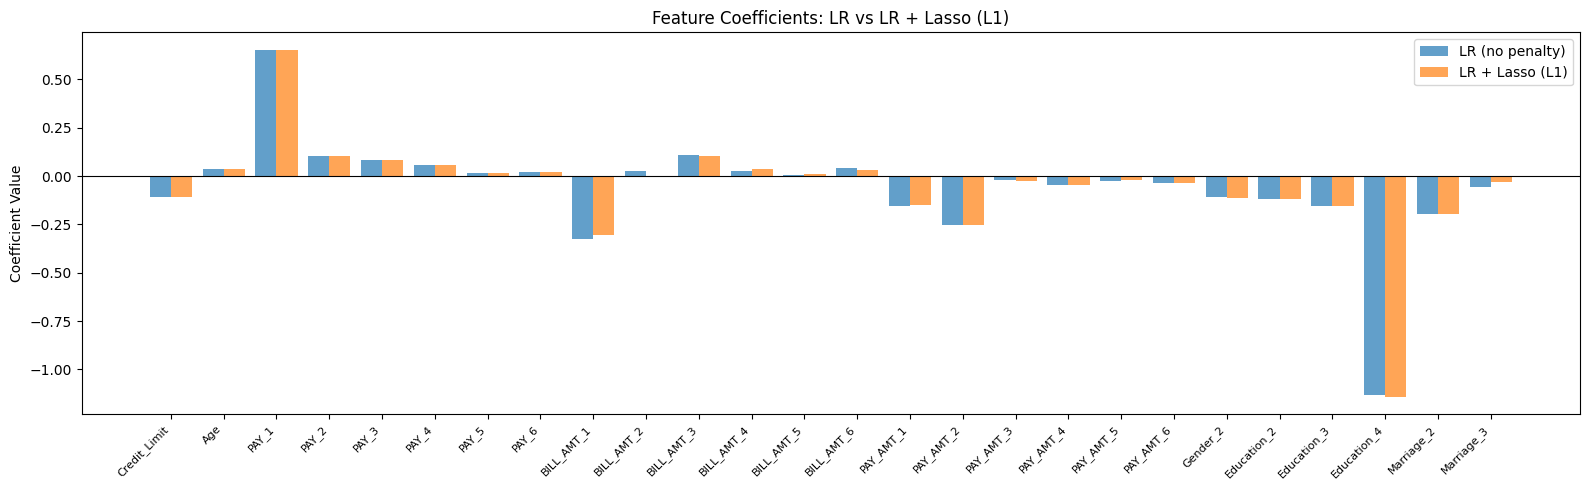

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# --- Accuracy comparison ---
lr_train     = results['Logistic Regression']['train_acc']
lr_val       = results['Logistic Regression']['val_acc']
lasso_train  = results['LR + Lasso (L1)']['train_acc']
lasso_val    = results['LR + Lasso (L1)']['val_acc']

print("=== LR vs LR + Lasso Comparison ===")
print(f"{'Model':<22} | {'Train Acc':>10} | {'Val Acc':>10}")
print("-" * 48)
print(f"{'Logistic Regression':<22} | {lr_train:>10.4f} | {lr_val:>10.4f}")
print(f"{'LR + Lasso (L1)':<22} | {lasso_train:>10.4f} | {lasso_val:>10.4f}")

# --- Coefficient comparison bar chart ---
feature_names = X_train.columns.tolist()
coef_lr    = lr.coef_[0]
coef_lasso = lr_lasso.coef_[0]

x = np.arange(len(feature_names))
width = 0.4

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(x - width/2, coef_lr,    width, label='LR (no penalty)', alpha=0.7)
ax.bar(x + width/2, coef_lasso, width, label='LR + Lasso (L1)', alpha=0.7)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(feature_names, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Coefficient Value')
ax.set_title('Feature Coefficients: LR vs LR + Lasso (L1)')
ax.legend()
plt.tight_layout()
plt.show()

### 4.2 Random Forest

**How it works:** Random Forest builds many independent **decision trees** (here, 200) during training, each trained on a random subset of data (bootstrap sampling) and a random subset of features at each split. The final prediction is the **majority vote** across all trees.

$$\hat{y} = \text{mode}\left(\{ T_1(x), T_2(x), \ldots, T_N(x) \}\right)$$

**Why use it here:**
- Handles non-linear relationships and feature interactions naturally
- Robust to outliers and doesn't require feature scaling (though we scaled anyway)
- Provides **feature importance** scores — useful for understanding which variables drive default risk
- Rarely overfits due to averaging across many trees

**Key parameters:**
- `n_estimators=200` — 200 trees for a good bias-variance trade-off
- `n_jobs=-1` — use all CPU cores to speed up training

In [17]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

train_acc = accuracy_score(y_train, rf.predict(X_train))
val_acc   = accuracy_score(y_val,   rf.predict(X_val))
results['Random Forest'] = {'model': rf, 'train_acc': train_acc, 'val_acc': val_acc}

print(f"Random Forest       | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

Random Forest       | Train Acc: 0.9995 | Val Acc: 0.8122


### 4.3 Gradient Boosting

**How it works:** Gradient Boosting builds trees **sequentially**, where each new tree corrects the **residual errors** of all previous trees. It minimizes a loss function by following the negative gradient:

$$F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$$

where $h_m$ is the new tree fitted to the residuals and $\eta$ is the learning rate.

**Why use it here:**
- Generally one of the strongest classifiers for tabular data
- Captures complex, non-linear patterns while reducing bias step by step
- More accurate than Random Forest in many cases, at the cost of slower training

**Key parameters:**
- `n_estimators=200` — number of boosting stages (trees)
- Sequential by nature, so `n_jobs` parallelism is not available

In [18]:
gb = GradientBoostingClassifier(n_estimators=200, random_state=42)
gb.fit(X_train, y_train)

train_acc = accuracy_score(y_train, gb.predict(X_train))
val_acc   = accuracy_score(y_val,   gb.predict(X_val))
results['Gradient Boosting'] = {'model': gb, 'train_acc': train_acc, 'val_acc': val_acc}

print(f"Gradient Boosting   | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

Gradient Boosting   | Train Acc: 0.8344 | Val Acc: 0.8184


### 4.4 K-Nearest Neighbors (KNN)

**How it works:** KNN is a **non-parametric, instance-based** algorithm. To classify a new sample, it finds the $k$ closest training samples (by Euclidean distance) and assigns the majority class among them:

$$\hat{y} = \text{mode}\left(\{ y_i \mid x_i \in \text{k-nearest neighbors of } x \}\right)$$

There is **no explicit training phase** — the model simply memorizes all training data and computes distances at prediction time.

**Why use it here:**
- Simple and intuitive, good for understanding decision boundaries
- No assumptions about data distribution
- Sensitive to feature scale — which is why `StandardScaler` was applied beforehand

**Key parameters:**
- `n_neighbors=5` — use the 5 nearest neighbors to vote
- `n_jobs=-1` — parallelize distance computations across CPU cores

In [19]:
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_train, y_train)

train_acc = accuracy_score(y_train, knn.predict(X_train))
val_acc   = accuracy_score(y_val,   knn.predict(X_val))
results['KNN'] = {'model': knn, 'train_acc': train_acc, 'val_acc': val_acc}

print(f"KNN                 | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

KNN                 | Train Acc: 0.8450 | Val Acc: 0.7947


### 4.5 Support Vector Machine (SVM)

**How it works:** SVM finds the **optimal hyperplane** that maximizes the margin between classes. With the RBF (Radial Basis Function) kernel, it maps inputs into a high-dimensional space where a linear boundary can separate non-linearly separable data:

$$K(x_i, x_j) = \exp\left(-\gamma \|x_i - x_j\|^2\right)$$

The model only depends on a subset of training points called **support vectors** — those closest to the decision boundary.

**Why use it here:**
- Effective in high-dimensional spaces (we have many features after OHE)
- RBF kernel captures non-linear patterns without explicitly computing the transformation
- Requires feature scaling — already handled by `StandardScaler`

**Key parameters:**
- `kernel='rbf'` — uses the RBF kernel for non-linear classification
- `probability=True` — enables `predict_proba()` needed for ROC-AUC evaluation

In [20]:
svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train, y_train)

train_acc = accuracy_score(y_train, svm.predict(X_train))
val_acc   = accuracy_score(y_val,   svm.predict(X_val))
results['SVM'] = {'model': svm, 'train_acc': train_acc, 'val_acc': val_acc}

print(f"SVM                 | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

SVM                 | Train Acc: 0.8265 | Val Acc: 0.8144


### 4.6 Model Comparison (Validation Set)

In [21]:
import pandas as pd

# Summary of all models on validation set
summary_val = pd.DataFrame([
    {'Model': name, 'Train Acc': res['train_acc'], 'Val Acc': res['val_acc']}
    for name, res in results.items()
]).set_index('Model').sort_values('Val Acc', ascending=False)

print("=== Validation Accuracy Summary ===")
print(summary_val.round(4).to_string())

# Select best model for final evaluation
best_name  = summary_val['Val Acc'].idxmax()
best_model = results[best_name]['model']
print(f"\n✅ Best model selected: {best_name} (Val Acc: {summary_val.loc[best_name, 'Val Acc']:.4f})")

=== Validation Accuracy Summary ===
                     Train Acc  Val Acc
Model                                  
Gradient Boosting       0.8344   0.8184
SVM                     0.8265   0.8144
Random Forest           0.9995   0.8122
Logistic Regression     0.8133   0.8089
KNN                     0.8450   0.7947

✅ Best model selected: Gradient Boosting (Val Acc: 0.8184)


## 5. Evaluate

FINAL EVALUATION ON TEST SET
                     Accuracy  Precision  Recall      F1  AUC-ROC
Model                                                            
Random Forest          0.8124     0.6310  0.3675  0.4645   0.7637
Gradient Boosting      0.8147     0.6467  0.3584  0.4612   0.7827
SVM                    0.8131     0.6541  0.3303  0.4390   0.7102
KNN                    0.7940     0.5537  0.3574  0.4344   0.7015
Logistic Regression    0.8093     0.7066  0.2369  0.3549   0.7187


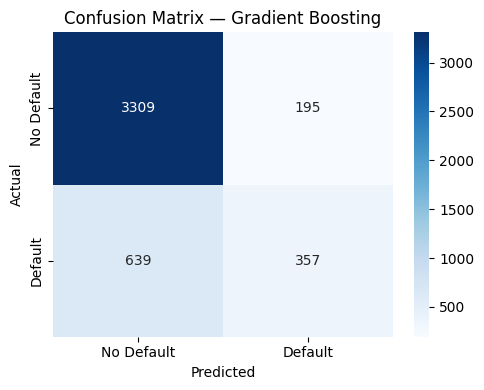


Classification Report — Gradient Boosting:
              precision    recall  f1-score   support

  No Default       0.84      0.94      0.89      3504
     Default       0.65      0.36      0.46       996

    accuracy                           0.81      4500
   macro avg       0.74      0.65      0.67      4500
weighted avg       0.80      0.81      0.79      4500



In [22]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, f1_score, precision_score, recall_score)
import matplotlib.pyplot as plt
import seaborn as sns

# --- Evaluate all models on the TEST set ---
print("=" * 70)
print("FINAL EVALUATION ON TEST SET")
print("=" * 70)

eval_rows = []
for name, res in results.items():
    model = res['model']
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    eval_rows.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1':        f1_score(y_test, y_pred),
        'AUC-ROC':   roc_auc_score(y_test, y_prob),
    })

eval_df = pd.DataFrame(eval_rows).set_index('Model').sort_values('F1', ascending=False)
print(eval_df.round(4).to_string())

# --- Confusion matrix for the best model ---
y_pred_best = best_model.predict(X_test)

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
ax.set_title(f'Confusion Matrix — {best_name}')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

# --- Classification report for the best model ---
print(f"\nClassification Report — {best_name}:")
print(classification_report(y_test, y_pred_best, target_names=['No Default', 'Default']))

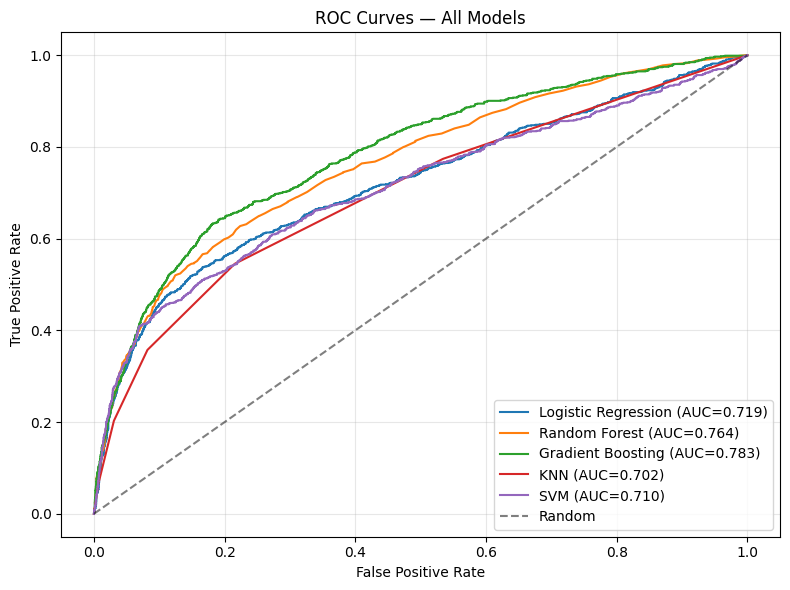

In [23]:
from sklearn.metrics import roc_curve

# ROC curves for all models
fig, ax = plt.subplots(figsize=(8, 6))
for name, res in results.items():
    y_prob = res['model'].predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Conclusion

In [24]:
# Summary table
print("=== Model Comparison Summary ===\n")
summary = eval_df.copy()
summary['Rank'] = range(1, len(summary) + 1)
print(summary[['Rank', 'Accuracy', 'F1', 'AUC-ROC']].round(4).to_string())
print(f"\n→ Recommended model: {best_name}")
print(f"  - Best F1 on test set: {eval_df.loc[best_name, 'F1']:.4f}")
print(f"  - AUC-ROC: {eval_df.loc[best_name, 'AUC-ROC']:.4f}")

=== Model Comparison Summary ===

                     Rank  Accuracy      F1  AUC-ROC
Model                                               
Random Forest           1    0.8124  0.4645   0.7637
Gradient Boosting       2    0.8147  0.4612   0.7827
SVM                     3    0.8131  0.4390   0.7102
KNN                     4    0.7940  0.4344   0.7015
Logistic Regression     5    0.8093  0.3549   0.7187

→ Recommended model: Gradient Boosting
  - Best F1 on test set: 0.4612
  - AUC-ROC: 0.7827


## Overfitting check
Comparing Train AUC vs Test AUC for each model. A large gap (> ~0.05) would indicate overfitting.


## Feature Importance 